In [269]:
import nest, pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

In [270]:
word = "aaaa"


# 1) Reset & disable plasticity
nest.ResetKernel()
nest.set(
    resolution               = 1.0,
    rng_seed                 = 1,
    eprop_update_interval    = 1e9,     # never update during inference
    eprop_learning_window    = 1e9,
    eprop_reset_neurons_on_update = False
)


Feb 13 18:49:47 correlation_detector [Info]: 
    Default for delta_tau changed from 0.5 to 5 ms

Feb 13 18:49:47 correlomatrix_detector [Info]: 
    Default for delta_tau changed from 0.5 to 5 ms

Feb 13 18:49:47 correlospinmatrix_detector [Info]: 
    Default for delta_tau changed from 0.1 to 1 ms

Feb 13 18:49:47 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 1 ms.


In [271]:
# 2) Recreate the devices & populations (same as the training ones)
n_in, n_rec, n_out = 300, 500, 3

tau_m_mean = 30.0

params_nrn_rec = {
    "adapt_tau": 2000.0,  # ms, time constant of adaptive threshold
    "C_m": 250.0,  # pF, membrane capacitance - takes effect only if neurons get current input (here not the case)
    "c_reg": 150.0,  # firing rate regularization scaling
    "E_L": 0.0,  # mV, leak / resting membrane potential
    "f_target": 20.0,  # spikes/s, target firing rate for firing rate regularization
    "gamma": 0.3,  # scaling of the pseudo derivative
    "I_e": 0.0,  # pA, external current input
    "regular_spike_arrival": False,  # If True, input spikes arrive at end of time step, if False at beginning
    "surrogate_gradient_function": "piecewise_linear",  # surrogate gradient / pseudo-derivative function
    "t_ref": 0.0,  # ms, duration of refractory period
    "tau_m": nest.random.normal(mean=tau_m_mean, std=2.0),  # ms, membrane time constant
    "V_m": 0.0,  # mV, initial value of the membrane voltage
    "V_th": 0.03,  # mV, spike threshold membrane voltage
}

params_nrn_rec["adapt_beta"] = (
    1.7 * (1.0 - np.exp(-1 / params_nrn_rec["adapt_tau"])) / (1.0 - np.exp(-1.0 / tau_m_mean))
)  # prefactor of adaptive threshold

params_nrn_out = {
    "C_m": 1.0,
    "E_L": 0.0,
    "I_e": 0.0,
    "loss": "mean_squared_error",  # loss function
    "regular_spike_arrival": False,
    "tau_m": 50.0,
    "V_m": 0.0,
}

gen_spk_in = nest.Create("spike_generator", n_in)
nrns_in    = nest.Create("parrot_neuron",          n_in)
nrns_rec   = nest.Create("eprop_iaf_adapt_bsshslm_2020", n_rec, params_nrn_rec)
nrns_out   = nest.Create("eprop_readout_bsshslm_2020",  n_out, params_nrn_out)

In [272]:
# 3) Load & set the frozen input spikes
#with open("saved_model/params_gen_spk_in_a.pkl","rb") as f:
#    frozen_input = pickle.load(f)

In [273]:
def build_frozen_input(letter, n_in, seq, step = 1.0,  p = 0.05,
                      jitter_ms: float = 0.0,
                      zero_first = True, dtype = np.float32):    
    """
    Generate one sequence (seq time-steps) of frozen Poisson noise
    for n_in neurons, re-seeded by `letter`.
    Returns a list of length n_in of dicts {"spike_times": array([...])}.
    """
    # 1) reseed RNG per letter
    np.random.seed(ord(letter)*1000)   

    # 2) draw a boolean matrix [seq x n_in]
    masks = (np.random.rand(seq, n_in) < p)        
    if zero_first:
        masks[0, :] = False

    # 3) for each neuron, convert mask→times
    params = []
    times_grid = np.arange(seq) * step
    for neuron_idx in range(n_in):
        spikes = times_grid[masks[:, neuron_idx]]
        params.append({"spike_times": spikes.astype(dtype)})
    return params


def build_word_input(word: str,
                     n_in: int,
                     seq: int,
                     step: float = 1.0,
                     p: float = 0.05,
                     dtype=np.float32) -> list[dict]:
    """
    Create a single spike‐generator config that runs letter1, letter2, … letterN back-to-back.
    Returns a list of length n_in of {"spike_times": array([...])} for the whole word.
    """
    # pre-allocate per‐neuron lists
    per_neuron_spikes = [[] for _ in range(n_in)]
    
    for i, letter in enumerate(word):
        # 1) generate the 1× pattern for this letter
        letter_params = build_frozen_input(letter, n_in=n_in, seq=seq, step=step, p=p)
        offset = i * seq * step  # ms shift for this letter
        
        # 2) append it (with offset) into each neuron’s list
        for neuron_idx in range(n_in):
            ts = letter_params[neuron_idx]["spike_times"]
            per_neuron_spikes[neuron_idx].append(ts + offset)
    
    # 3) flatten each neuron’s list and pack into the NEST format
    combined = []
    for neuron_list in per_neuron_spikes:
        all_ts = np.hstack(neuron_list).astype(dtype)
        combined.append({"spike_times": all_ts})
    return combined

In [274]:
with open("saved_model/seq_ms.pkl","rb") as f: #load in the saved time for on sequence from training
    seq_ms = pickle.load(f)

params_gen_spk_in = build_word_input(word, n_in=n_in, seq=int(seq_ms), p=0.05)

In [275]:
# 4) Load the trained weight matrices
model = f"saved_model/weights_post_train_a_0.5-jitter.pkl"
with open(model,"rb") as f:
    wt = pickle.load(f)
# wt["in_rec"]["weight_matrix"] is the trained (n_rec×n_in) array
# wt["rec_rec"]["weight_matrix"] is (n_rec×n_rec)
# wt["rec_out"]["weight_matrix"] is (n_out×n_rec)

w_in  = wt["in_rec"]["weight_matrix"]
w_rec = wt["rec_rec"]["weight_matrix"]
w_out = wt["rec_out"]["weight_matrix"]

In [276]:
# 5) Reconnect using the saved weights (static synapses, since no learning)
params_conn_all_to_all = {"rule": "all_to_all", "allow_autapses": False}
syn_params = {"synapse_model": "static_synapse", "delay": 1.0}

nest.Connect(gen_spk_in, nrns_in,   {"rule":"one_to_one"}, syn_params)
nest.Connect(nrns_in,    nrns_rec,  params_conn_all_to_all, {**syn_params, "weight": w_in})
nest.Connect(nrns_rec,   nrns_rec,  params_conn_all_to_all, {**syn_params, "weight": w_rec})
nest.Connect(nrns_rec,   nrns_out,  params_conn_all_to_all, {**syn_params, "weight": w_out})

#

In [277]:
def build_network_and_load_weights():
    # --- 1) Create all the network elements ---
    gen_spk_in = nest.Create("spike_generator", n_in)
    nrns_in    = nest.Create("parrot_neuron", n_in)
    nrns_rec   = nest.Create("eprop_iaf_adapt_bsshslm_2020", n_rec, params_nrn_rec)
    nrns_out   = nest.Create("eprop_readout_bsshslm_2020",  n_out, params_nrn_out)

    # --- 2) Load your saved weight matrices ---
    with open(model, "rb") as f:
        w = pickle.load(f)
    W_in_rec  = w["in_rec"]["weight_matrix"]
    W_rec_rec = w["rec_rec"]["weight_matrix"]
    W_rec_out = w["rec_out"]["weight_matrix"]

    # --- 3) Connect everything using static_synapse + loaded weights ---
    one2one = {"rule": "one_to_one"}
    all2all = {"rule": "all_to_all", "allow_autapses": False}
    syn_static = {"synapse_model": "static_synapse", "delay": 1.0}

    # spike_generator → parrot neurons
    nest.Connect(gen_spk_in, nrns_in, one2one, syn_static)
    # parrot → recurrent
    nest.Connect(nrns_in, nrns_rec, all2all, {**syn_static, "weight": W_in_rec})
    # recurrent → recurrent
    nest.Connect(nrns_rec, nrns_rec, all2all, {**syn_static, "weight": W_rec_rec})
    # recurrent → readout
    nest.Connect(nrns_rec, nrns_out, all2all, {**syn_static, "weight": W_rec_out})

    # --- 4) Set up the readout recorder ---
    mm_out = nest.Create("multimeter", {
        "record_from": ["readout_signal"],
        "interval":    1.0,
        "start":       0.0,
        "stop":        seq_ms
    })
    nest.Connect(mm_out, nrns_out, all2all)

    # Return the pieces you’ll need downstream
    return gen_spk_in, nrns_in, nrns_rec, nrns_out, mm_out


In [278]:
def jitter_params(params, jitter_ms: float, rng: np.random.RandomState, step: float):
    """
    Add ±jitter_ms to each spike, snap back onto the 'step' grid,
    then clamp everything into [step, t_max], dedupe and sort.
    """
    out = []
    for p in params:
        t = p["spike_times"]
        if t.size == 0:
            out.append({"spike_times": t})
            continue

        # 1) add uniform noise
        t_j = t + rng.uniform(-jitter_ms, +jitter_ms, size=t.shape)

        # 2) quantize back onto the simulation grid
        t_q = np.round(t_j / step) * step

        # 3) clamp into [step, t.max()]
        t_q = np.clip(t_q, step, t.max())

        # 4) remove duplicates & sort
        t_u = np.unique(t_q).astype(t.dtype)

        out.append({"spike_times": t_u})
    return out

In [284]:
# 0) Prepare
letter_trajs_raw = []   # will hold (x_full, y_full, pen_full) for each letter
jitter_ms = 7
# 1) Inference loop: fill letter_trajs_raw
for letter in word:
    nest.ResetKernel()
    nest.set(
        resolution=1,
        rng_seed=1,
        eprop_update_interval=1e9,
        eprop_learning_window=1e9,
        eprop_reset_neurons_on_update=False,
    )
    gen_spk_in, nrns_in, nrns_rec, nrns_out, mm_out = build_network_and_load_weights()

    # drive & simulate one letter
    params = build_frozen_input(letter, n_in=n_in, seq=int(seq_ms))
    rng = np.random.RandomState()
    params = jitter_params(params, jitter_ms, step=1.0, rng=rng) 
    nest.SetStatus(gen_spk_in, params)
    nest.Simulate(seq_ms)

    # grab readout events
    ev      = mm_out.get("events")
    senders = ev["senders"]
    signals = ev["readout_signal"]

    # split into X, Y, Pen
    ids      = sorted(np.unique(senders))  # e.g. [401,402,403]
    x_full   = signals[senders == ids[0]]
    y_full   = signals[senders == ids[1]]
    pen_full = signals[senders == ids[2]]

    print("\n---- SINGLE LETTER ----")
    print("len:", len(x_full))
    print("x range:", float(np.min(x_full)), float(np.max(x_full)))
    print("y range:", float(np.min(y_full)), float(np.max(y_full)))
    print("pen down %:", float(np.mean(pen_full > 0.5)))
    print("dx std:", float(np.std(np.diff(x_full))))
    print("dy std:", float(np.std(np.diff(y_full))))

    # drop warm-up
    warm_ms = 0
    x_full   = x_full  [warm_ms:]
    y_full   = y_full  [warm_ms:]
    pen_full = pen_full[warm_ms:]

    letter_trajs_raw.append((x_full, y_full, pen_full))
    
    print("\n---- WORD TRAJECTORIES ----")
    for i, (x, y, p) in enumerate(letter_trajs_raw):
        print(
            f"letter {i}: len={len(x)}, "
            f"pen_down={np.mean(p>0.5):.2f}, "
            f"dx_std={np.std(np.diff(x)):.4f}"
        )




Feb 13 18:50:25 correlation_detector [Info]: 
    Default for delta_tau changed from 0.5 to 5 ms

Feb 13 18:50:25 correlomatrix_detector [Info]: 
    Default for delta_tau changed from 0.5 to 5 ms

Feb 13 18:50:25 correlospinmatrix_detector [Info]: 
    Default for delta_tau changed from 0.1 to 1 ms

Feb 13 18:50:25 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 1 ms.

Feb 13 18:50:25 NodeManager::prepare_nodes [Info]: 
    Preparing 1104 nodes for simulation.

Feb 13 18:50:25 SimulationManager::start_updating_ [Info]: 
    Number of local nodes: 1104
    Simulation time (ms): 392
    Number of OpenMP threads: 1
    Number of MPI processes: 1

Feb 13 18:50:25 SimulationManager::run [Info]: 
    Simulation finished.

---- SINGLE LETTER ----
len: 391
x range: -0.3557040074110454 0.49041840463232117
y range: -0.5920046021226741 0.5871670697220165
pen down %: 0.989769820971867
dx std: 0.013955154345575194
dy std: 0.022046965523614983

---- WORD TRAJECTO

speed mean/std: 0.016240560947431933 0.017817828018482192
[smooth] segment 4:391 len=387
[plot] letter a: len=391, pen_down=0.99, width=0.846
[smooth] segment 4:391 len=387
[plot] letter a: len=391, pen_down=0.99, width=0.828
[smooth] segment 4:391 len=387
[plot] letter a: len=391, pen_down=0.99, width=0.848
[smooth] segment 4:391 len=387
[plot] letter a: len=391, pen_down=0.99, width=0.824


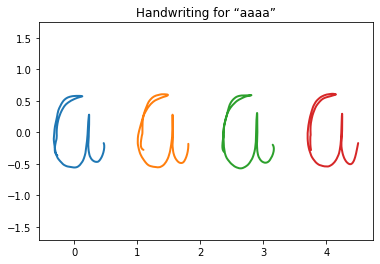

In [285]:
# 2) Plot them side by side, inserting NaN at pen-up (with stroke smoothing)

def smooth_pen_down_segments(x, y, pen, pen_thr=0.5, win=11, poly=3):
    x = np.asarray(x).copy()
    y = np.asarray(y).copy()
    pen = np.asarray(pen)

    down = pen > pen_thr
    if down.sum() < 3:
        return x, y

    # indices where pen state changes
    idx = np.flatnonzero(np.diff(down.astype(int)) != 0) + 1
    cuts = np.r_[0, idx, len(down)]

    for a, b in zip(cuts[:-1], cuts[1:]):        
        if not down[a]:
            continue  

        n = b - a
        print(f"[smooth] segment {a}:{b} len={n}")    

        if n < 5:
            continue  # too short to smooth reliably

        # window must be odd and <= n
        w = min(win, n if n % 2 == 1 else n - 1)
        if w < 5:
            continue

        p = min(poly, w - 2)  
        x[a:b] = savgol_filter(x[a:b], window_length=w, polyorder=p, mode="interp")
        y[a:b] = savgol_filter(y[a:b], window_length=w, polyorder=p, mode="interp")

    return x, y

spacing = 0.5
plt.figure(figsize=(6, 4))
x_offset = 0.0

speed = np.sqrt(np.diff(x_full)**2 + np.diff(y_full)**2)
print("speed mean/std:", float(speed.mean()), float(speed.std()))

for (x_full, y_full, pen_full), L in zip(letter_trajs_raw, word):
    x_s, y_s = smooth_pen_down_segments(
        x_full, -y_full, pen_full,
        pen_thr=0.5,
        win=41,      
    )

    # break pen-up parts
    x_plot = x_s.copy()
    y_plot = y_s.copy()
    up_mask = pen_full <= 0.5
    x_plot[up_mask] = np.nan
    y_plot[up_mask] = np.nan

    print(
    f"[plot] letter {L}: "
    f"len={len(x_full)}, "
    f"pen_down={np.mean(pen_full>0.5):.2f}, "
    f"width={np.nanmax(x_full)-np.nanmin(x_full):.3f}"
    )

    plt.plot(
        x_plot + x_offset, y_plot,
        lw=2,
        label=L,
        solid_joinstyle="round",
        solid_capstyle="round",
        antialiased=True,
    )

    width = np.nanmax(x_full) - np.nanmin(x_full)
    x_offset += width + spacing

plt.axis("equal")
plt.title(f"Handwriting for “{word}”")
plt.show()

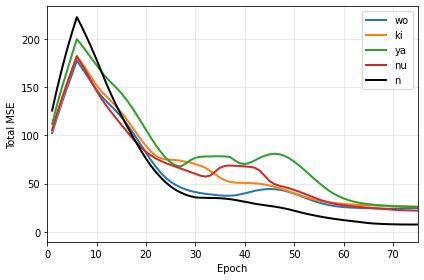

In [286]:
# 1) specify the experimental setups and corresponding CSVs
setups = {
    "wo":  "images/epoch_loss_w_1000iter.csv",
    "ki": "images/epoch_loss_ki_1000iter.csv",
    "ya": "images/epoch_loss_y_1000iter.csv",
    "nu": "images/epoch_loss_nu_1000iter.csv",
    "n": "images/epoch_loss_n_1000iter.csv",
}

plt.figure(figsize=(6,4))
for label, fn in setups.items():
    # load columns: epoch, MSE_x, MSE_y, MSE_pen, MSE_total
    data = np.loadtxt(fn, delimiter=",", skiprows=1)

    w = 10  # adjust: larger → smoother
    kernel = np.ones(w) / w
    epochs     = data[:,0]
    mse_total  = data[:,4]
    mse_total = np.convolve(mse_total, kernel, mode="same")

    if label == "n":
        col = "black"
    else:
        col = None
        
    plt.plot(epochs, mse_total, label=label, lw=2, color=col)



plt.xlabel("Epoch")
plt.ylabel("Total MSE")
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(0, 75)
plt.tight_layout()
plt.savefig("images/loss_vs_epoch_all.pdf", dpi=300)
plt.show()